In [2]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
h1 = 1
m = 0.5

def coupling(matrix_1, matrix_2):
    s11_1, s12_1 = matrix_1[0, 0], matrix_1[0, 1]
    s21_1, s22_1 = matrix_1[1, 0], matrix_1[1, 1]
    s11_2, s12_2 = matrix_2[0, 0], matrix_2[0, 1]
    s21_2, s22_2 = matrix_2[1, 0], matrix_2[1, 1]
    
    denom = 1 - s11_2 * s22_1
    s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
    s12 = s12_1 * s12_2 / denom
    s21 = s21_2 * s21_1 / denom
    s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom
    
    return np.array([[s11, s12], [s21, s22]], dtype=np.complex128)

def multiple_coupling(matrix_collect):
    result = matrix_collect[0]
    for matrix in matrix_collect[1:]:
        result = coupling(result, matrix)
    return result

def coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a):
    constant_1 = 2 * m * (y1 + 1j * y2) / (h1**2)
    constant_2 = 2 * m * (y1 - 1j * y2) / (h1**2)
    
    di = np.array([constant_1 if i % 2 == 0 or i >= 2 * N and i < 2 * N + n3 else constant_2 
                   for i in range(2 * N + n3 + n4)], dtype=complex)
    
    x_0 = 0
    x_1 = a * (2 * N + n3 + n4) - a + x_0
    location = np.linspace(x_0, x_1, 2 * N + n3 + n4)
 #   print(location)
    k = np.sqrt(E * 2 * m) / h1
    exp_2jk = np.exp(2j * k * location)
    exp_minus_2jk = np.exp(-2j * k * location)
    
    matrix_collect = np.zeros((2 * N + n3 + n4, 2, 2), dtype=complex)
    for i in range(2 * N + n3 + n4):
        s11 = di[i] * exp_2jk[i]
        s12 = 2j * k
        s21 = 2j * k
        s22 = di[i] * exp_minus_2jk[i]
        
        matrix_collect[i] = np.array([[s11, s12], [s21, s22]]) / (-di[i] + 2j * k)
  #  print(matrix_collect)
    return multiple_coupling(matrix_collect)

def Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a):
    matrix = coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a)
    return float(np.abs(matrix[1, 0])**2)

def Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a):
    matrix = coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a)
    return float(np.abs(matrix[0, 0])**2)

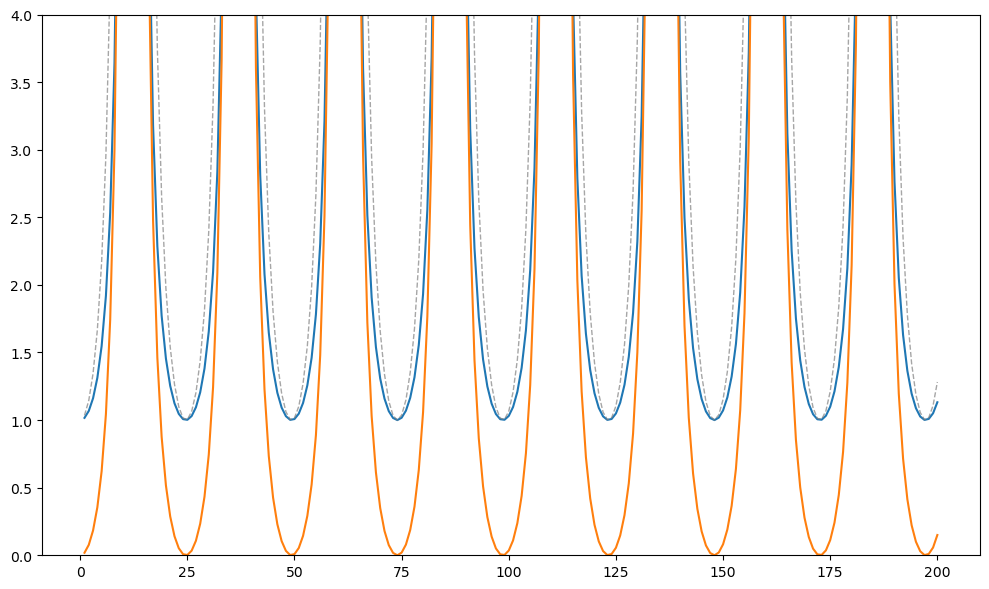

In [2]:
import numpy as np                         #T&R          #最终25.4.10
import matplotlib.pyplot as plt
import os
# 绘图参数        
N = 100
n3 = 0
n4 = 0
y1 = 0  # y1 的不同取值
y2 = 2   # y2 的不同取值
E= 246.7726707458496
a=0.5
N1= np.arange(1, 201) 
T_11 =[Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for N in N1]
R_11 =[Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for N in N1]
Sum_values = [T + R for T, R in zip(T_11, R_11)]
# 绘制图形
plt.figure(figsize=(10, 6))
plt.plot(N1,T_11)  
plt.plot(N1,R_11)  
plt.plot(N1, Sum_values, 
         color='gray',   # 灰色
         linestyle='--', # 虚线
         linewidth=1,    # 线宽
         alpha=0.7)      # 透明度
#plt.xlabel('Energy (E)', fontsize=12)
#plt.ylabel('Quantum Number (K)', fontsize=12)
#plt.title('Energy Levels Distribution', fontsize=14)
#plt.grid(True, linestyle='--', alpha=0.6)

#plt.xlim(max(0, E_min), min(E_max, max(E_array)*1.1))
plt.ylim(0,4)

plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

数据已保存至: C:\Users\taoji\Desktop\结果\1\N_n30_n40_y10_y22_E246.7726707458496.xlsx


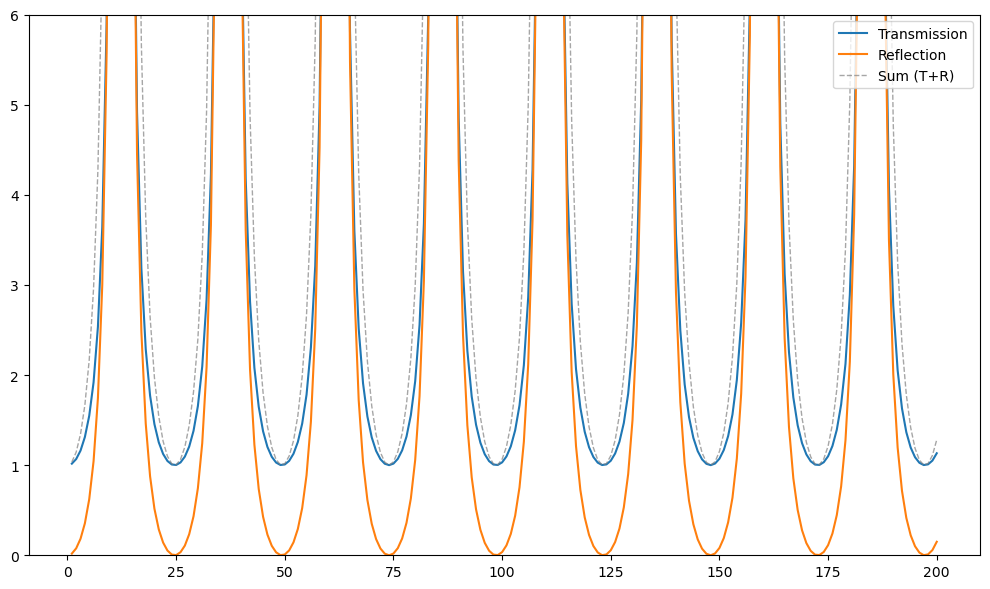

In [15]:
# 创建DataFrame保存数据
data = {
    'a1': N1,
    'T_11': T_11,
    'R_11': R_11,
    'Sum_values': Sum_values
}
df = pd.DataFrame(data)

# 创建保存路径
save_dir = r"C:\Users\taoji\Desktop\结果\1"
os.makedirs(save_dir, exist_ok=True)

# 按参数命名文件
filename = f"N_n3{n3}_n4{n4}_y1{y1}_y2{y2}_E{E}.xlsx"
save_path = os.path.join(save_dir, filename)

# 保存到Excel
df.to_excel(save_path, index=False)
print(f"数据已保存至: {save_path}")

# 绘制图形
plt.figure(figsize=(10, 6))
plt.plot(N1, T_11, label='Transmission')  
plt.plot(N1, R_11, label='Reflection')  
plt.plot(N1, Sum_values, 
         color='gray', linestyle='--', 
         linewidth=1, alpha=0.7,
         label='Sum (T+R)')

plt.ylim(0, 6)
plt.legend()
plt.tight_layout()
plt.show()

数据已保存至: C:\Users\taoji\Desktop\结果\1\25.4.16\N1_n30_n40_y10_y26_E0.1.xlsx


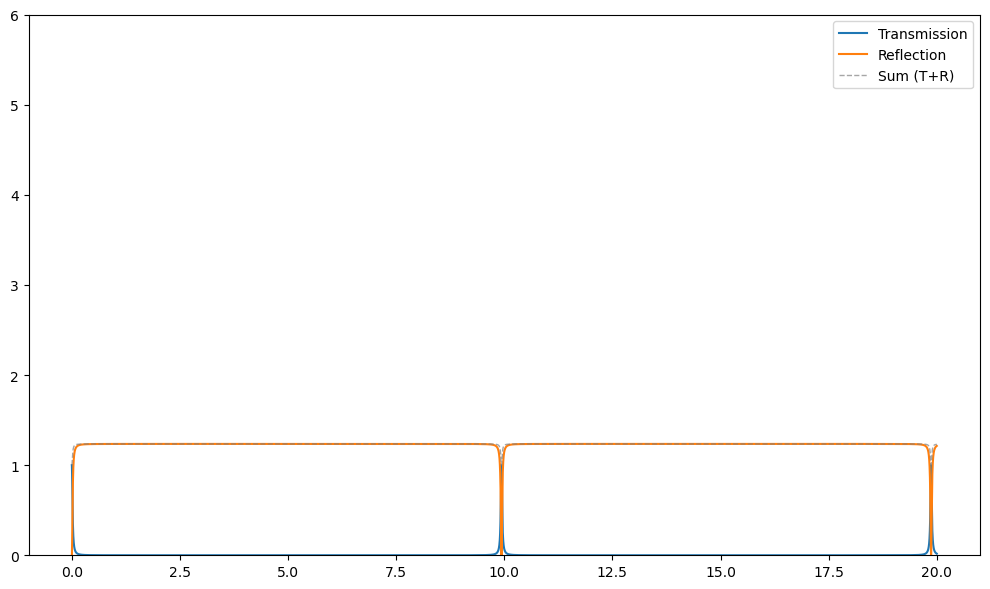

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# 参数设置
N = 100
n3 = 0
n4 = 0
y1 = 2
y2 = 2
E = 0.1
a1 = np.linspace(0, 20, 10000)

# 计算数据
T_11 = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for a in a1]
R_11 = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for a in a1]
Sum_values = [T + R for T, R in zip(T_11, R_11)]

# 创建DataFrame保存数据
data = {
    'a1': a1,
    'T_11': T_11,
    'R_11': R_11,
    'Sum_values': Sum_values
}
df = pd.DataFrame(data)

# 创建保存路径
save_dir = r"C:\Users\taoji\Desktop\结果\1\25.4.16"
os.makedirs(save_dir, exist_ok=True)

# 按参数命名文件
filename = f"N{N}_n3{n3}_n4{n4}_y1{y1}_y2{y2}_E{E}.xlsx"
save_path = os.path.join(save_dir, filename)

# 保存到Excel
df.to_excel(save_path, index=False)
print(f"数据已保存至: {save_path}")

# 绘制图形
plt.figure(figsize=(10, 6))
plt.plot(a1, T_11, label='Transmission')  
plt.plot(a1, R_11, label='Reflection')  
plt.plot(a1, Sum_values, 
         color='gray', linestyle='--', 
         linewidth=1, alpha=0.7,
         label='Sum (T+R)')

plt.ylim(0, 6)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
N = 100
n3 = 0
n4 = 0
y11 = [2]  # y1 的不同取值
y22 = [2]     # y2 的不同取值
a = 0.5
E=39.478417604357
Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a)+Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a)

0.9999999999999614

In [10]:
N = 100
n3 = 0
n4 = 0
y11 = [2]  # y1 的不同取值
y22 = [2]     # y2 的不同取值
a = 0.5
E=157.913670417430
Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a)+Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a)

1.0000000000000087

In [3]:
import numpy as np                         #T&R          #最终25.4.10
import matplotlib.pyplot as plt
import os
# 绘图参数        
N = 100
n3 = 0
n4 = 0
y11 = [2]  # y1 的不同取值
y22 = [0]     # y2 的不同取值
a = 0.5
zhi_1 = ['T','R','T+R']  # 选择绘制 T（透射系数）

# 能量范围
E_ranges = [(270,352)]  # 可以分段计算

# 输出文件夹
folder_name = "T&R实数与虚数_3"
output_dir = os.path.join(r"C:\Users\taoji\Desktop\结果\2025.4.12后_Python运行结果", folder_name)

# 确保输出目录存在
try:
    os.makedirs(output_dir, exist_ok=True)
    print(f"文件夹 '{output_dir}' 已创建或已存在")
except Exception as e:
    print(f"创建文件夹时出错: {e}")

# 遍历每个能量范围
for range_idx, (E_min, E_max) in enumerate(E_ranges):
    # 动态子图布局
    num_rows = len(y11)
    num_cols = len(y22)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(10 * num_cols, 6 * num_rows))
    fig.suptitle(f'Transmission/Reflection Coefficient)', fontsize=16)

    # 处理单行/单列情况
    if num_rows == 1 and num_cols == 1:
        axes = np.array([[axes]])
    elif num_rows == 1:
        axes = axes.reshape(1, -1)
    elif num_cols == 1:
        axes = axes.reshape(-1, 1)

    # 遍历 y11 和 y22 的组合
    for i, y1 in enumerate(y11):
        for j, y2 in enumerate(y22):
            E_values = np.linspace(E_min, E_max, 10000)
            T_values = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_values]
            R_values = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_values]
            Sum_values = [T + R for T, R in zip(T_values, R_values)]

            #临时存放
            #tao=dict(zip(E_values,T_values))

            
            ax = axes[i, j]
            if 'T' in zhi_1:
                ax.plot(E_values, T_values, label='Transmission (T)', color='blue')
            if 'R' in zhi_1:
                ax.plot(E_values, R_values, label='Reflection (R)', color='red')
            if 'T+R' in zhi_1:
                ax.plot(E_values, Sum_values, label='T + R', color='gray', linestyle='-')

            ax.set_xlabel('Energy (E)')
            ax.set_ylabel('Coefficient Value')
            ax.set_title(f'(N={N}, y1={y1}, y2={y2},k=10')

            
            #ax.axhline(y=1, color='green', linestyle='-', linewidth=1, alpha=0.7)
            ax.axvline(x=3.687850, color='green', linestyle='-', linewidth=1, alpha=0.7)
            #ax.axvline(x=47.240296550706, color='green', linestyle='-', linewidth=1, alpha=0.7)
            #ax.axvline(x=157.913670417430, color='green', linestyle='-', linewidth=1, alpha=0.7)
            #ax.axvline(x=165.848348494293, color='green', linestyle='-', linewidth=1, alpha=0.7)
            
            ax.legend()
            #ax.grid(True)
            ax.set_xlim(E_min, E_max)
            ax.set_ylim(0, 2)

    plt.tight_layout()

    # 保存图片
    y11_str = '_'.join(map(str, y11))
    y22_str = '_'.join(map(str, y22))
    zhi1_str = '_'.join(zhi_1)
    output_filename = os.path.join(
        output_dir,
        f'{range_idx + 1}_T&R({E_min},{E_max})_N={N}_n3={n3}_n4={n4}_y11={y11_str}_y22={y22_str}_a={a}_zhi1={zhi1_str}.png'
    )
    plt.savefig(output_filename, dpi=300)
    plt.close()
    print(f"已保存: {output_filename}")

文件夹 'C:\Users\taoji\Desktop\结果\2025.4.12后_Python运行结果\T&R实数与虚数_3' 已创建或已存在
已保存: C:\Users\taoji\Desktop\结果\2025.4.12后_Python运行结果\T&R实数与虚数_3\1_T&R(270,352)_N=100_n3=0_n4=0_y11=2_y22=0_a=0.5_zhi1=T_R_T+R.png


In [ ]:
# 绘图参数        最终  T$R_N
N1 = np.linspace(1,100,100)
for N in N1:
    N=int(N)
    n3 = 0
    n4 = 0
    y11 = [2]  # y1 的不同取值0
    y22 = [2]     # y2 的不同取值
    a = 0.5
    zhi_1 = ['T+R']  # 选择绘制 T（透射系数）
    
    # 能量范围
    E_ranges = [(0, 400)]  # 可以分段计算
    
    # 输出文件夹
    folder_name = "T&R实数与虚数_N"
    output_dir = os.path.join(r"C:\Users\taoji\Desktop\结果", folder_name)
    
    # 确保输出目录存在
    try:
        os.makedirs(output_dir, exist_ok=True)
        print(f"文件夹 '{output_dir}' 已创建或已存在")
    except Exception as e:
        print(f"创建文件夹时出错: {e}")
    
    # 遍历每个能量范围
    for range_idx, (E_min, E_max) in enumerate(E_ranges):
        # 动态子图布局
        num_rows = len(y11)
        num_cols = len(y22)
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
        fig.suptitle(f'Transmission and Reflection Coefficients vs Energy ({E_min} to {E_max})', fontsize=16)
    
        # 处理单行/单列情况
        if num_rows == 1 and num_cols == 1:
            axes = np.array([[axes]])
        elif num_rows == 1:
            axes = axes.reshape(1, -1)
        elif num_cols == 1:
            axes = axes.reshape(-1, 1)
    
        # 遍历 y11 和 y22 的组合
        for i, y1 in enumerate(y11):
            for j, y2 in enumerate(y22):
                E_values = np.linspace(E_min, E_max, 1000)
                T_values = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_values]
                R_values = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_values]
                Sum_values = [T + R for T, R in zip(T_values, R_values)]
    
                ax = axes[i, j]
                if 'T' in zhi_1:
                    ax.plot(E_values, T_values, label='Transmission (T)', color='blue')
                if 'R' in zhi_1:
                    ax.plot(E_values, R_values, label='Reflection (R)', color='red')
                if 'T+R' in zhi_1:
                    ax.plot(E_values, Sum_values, label='T + R', color='green', linestyle='--')
    
                ax.set_xlabel('Energy (E)')
                ax.set_ylabel('Coefficient Value')
                ax.set_title(f'y1={y1}, y2={y2}')
                ax.legend()
                ax.grid(True)
                ax.set_xlim(E_min, E_max)
                ax.set_ylim(0, 4)
    
        plt.tight_layout()
    
        # 保存图片
        y11_str = '_'.join(map(str, y11))
        y22_str = '_'.join(map(str, y22))
        zhi1_str = '_'.join(zhi_1)
        output_filename = os.path.join(
            output_dir,
            f'{range_idx + 1}_T&R({E_min},{E_max})_N={N}_n3={n3}_n4={n4}_y11={y11_str}_y22={y22_str}_a={a}_zhi1={zhi1_str}.png'
        )
        plt.savefig(output_filename, dpi=300)
        plt.close()
        print(f"已保存: {output_filename}")

In [3]:
import numpy as np                #25.5.3
import matplotlib.pyplot as plt
import os
# 绘图参数        
N = 100
n3 = 0
n4 = 0
y11 = [2]  # y1 的不同取值
y22 = [2]  # y2 的不同取值
a = 0.5
zhi_1 = ['T+R']  # 选择绘制 T（透射系数）

# 能量范围
E_ranges = [(0, 400)]  # 可以分段计算

# 输出文件夹
folder_name = "T&R实数与虚数"
output_dir = os.path.join(r"C:\Users\taoji\Desktop\结果\2025.5.3后_Python运行结果", folder_name)

# 确保输出目录存在
try:
    os.makedirs(output_dir, exist_ok=True)
    print(f"文件夹 '{output_dir}' 已创建或已存在")
except Exception as e:
    print(f"创建文件夹时出错: {e}")

# 遍历每个能量范围
for range_idx, (E_min, E_max) in enumerate(E_ranges):
    # 动态子图布局
    num_rows = len(y11)
    num_cols = len(y22)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    fig.suptitle(f'Transmission and Reflection Coefficients vs Energy ({E_min} to {E_max})', fontsize=16)

    # 处理单行/单列情况
    if num_rows == 1 and num_cols == 1:
        axes = np.array([[axes]])
    elif num_rows == 1:
        axes = axes.reshape(1, -1)
    elif num_cols == 1:
        axes = axes.reshape(-1, 1)

    # 遍历 y11 和 y22 的组合
    for i, y1 in enumerate(y11):
        for j, y2 in enumerate(y22):
            E_values = np.linspace(E_min, E_max, 100)
            T_values = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_values]
            R_values = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_values]
            Sum_values = [T + R for T, R in zip(T_values, R_values)]



            
            # 创建DataFrame保存数据
            data = {
                'E_values': E_values,
                'T_values': T_values,
                'R_values': R_values,
                'Sum_values': Sum_values
            }
            df = pd.DataFrame(data)
            
            # 创建保存路径
            save_dir = r"C:\Users\taoji\Desktop\结果\2025.5.3后_Python运行结果"
            os.makedirs(save_dir, exist_ok=True)
            
            # 按参数命名文件
            filename = f"N{N}_n3{n3}_n4{n4}_y1{y1}_y2{y2}.xlsx"
            save_path = os.path.join(save_dir, filename)
            
            # 保存到Excel
            df.to_excel(save_path, index=False)
            print(f"数据已保存至: {save_path}")



            
            ax = axes[i, j]
            if 'T' in zhi_1:
                ax.plot(E_values, T_values, label='Transmission (T)', color='blue')
            if 'R' in zhi_1:
                ax.plot(E_values, R_values, label='Reflection (R)', color='red')
            if 'T+R' in zhi_1:
                ax.plot(E_values, Sum_values, label='T + R', color='green', linestyle='--')

            ax.set_xlabel('Energy (E)')
            ax.set_ylabel('Coefficient Value')
            ax.set_title(f'y1={y1}, y2={y2}')
            ax.legend()
            ax.grid(True)
            ax.set_xlim(E_min, E_max)
            ax.set_ylim(0, 4)

    plt.tight_layout()

    # 保存图片
    y11_str = '_'.join(map(str, y11))
    y22_str = '_'.join(map(str, y22))
    zhi1_str = '_'.join(zhi_1)
    output_filename = os.path.join(
        output_dir,
        f'{range_idx + 1}_T&R({E_min},{E_max})_N={N}_n3={n3}_n4={n4}_y11={y11_str}_y22={y22_str}_a={a}_zhi1={zhi1_str}.png'
    )
    plt.savefig(output_filename, dpi=300)
    plt.close()
    print(f"已保存: {output_filename}")

文件夹 'C:\Users\taoji\Desktop\结果\2025.5.3后_Python运行结果\T&R实数与虚数' 已创建或已存在


C:\Users\taoji\AppData\Local\Temp\ipykernel_11784\3848482309.py:16: RuntimeWarning: invalid value encountered in scalar divide
  s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_11784\3848482309.py:17: RuntimeWarning: invalid value encountered in scalar divide
  s12 = s12_1 * s12_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_11784\3848482309.py:18: RuntimeWarning: invalid value encountered in scalar divide
  s21 = s21_2 * s21_1 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_11784\3848482309.py:19: RuntimeWarning: invalid value encountered in scalar divide
  s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom


数据已保存至: C:\Users\taoji\Desktop\结果\2025.5.3后_Python运行结果\N100_n30_n40_y12_y22.xlsx
已保存: C:\Users\taoji\Desktop\结果\2025.5.3后_Python运行结果\T&R实数与虚数\1_T&R(0,400)_N=100_n3=0_n4=0_y11=2_y22=2_a=0.5_zhi1=T+R.png
